# UAV GPS spoofing & jamming detection

**Kościuszkon 2026 - Honeywell Theme #2**

GPS is the only absolute-position sensor on most drones. A SDR like HackRF can
emit a stronger fake constellation, smoothly walking the receiver away from its
true position (spoofing), or just drowning the L1 band in noise (jamming).

This notebook trains a RandomForest on GPS receiver telemetry and compares it
against a physics-rules baseline, on the *Live GPS Spoofing and Jamming*
dataset (IEEE DataPort, ~10k samples). When the raw CSVs are not available
locally we fall back to a labelled simulation that exhibits the same physical
signatures (drift, HDOP/VDOP spikes, satellite drop-out) so the pipeline stays
reproducible.

In [13]:
import sys, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

sys.path.append(str(pathlib.Path.cwd().parent))
from gps_detection_utils import train_rf, evaluate, plot_results, compare_methods

RNG = np.random.default_rng(42)
plt.rcParams['figure.dpi'] = 90

## 1. Data - real CSV or labelled simulation

We try the real IEEE dataset first. If it isn't on disk we generate a
**time-ordered** flight with discrete attack windows: a smooth circular path
plus realistic 1 m GPS noise during normal flight, position drift during
spoofing windows, and HDOP/VDOP spikes plus satellite drop-out during jamming
windows. Generating attacks as *segments* (not random rows) keeps the temporal
structure intact, so position-derivative features remain physically meaningful.

In [14]:
def simulate_uav_flight(n=10067, attack_rate=0.194, rng=RNG):
    """Simulate a drone flight with discrete spoofing/jamming windows.

    Returns a time-ordered DataFrame whose feature distributions overlap
    between classes (so the task isn't trivial)."""
    t = np.arange(n)
    base_lat = 40.7128 + 5e-4 * np.sin(2 * np.pi * t / 2000)
    base_lon = -74.0060 + 1e-3 * np.sin(2 * np.pi * t / 1000)
    base_alt = 100 + 8 * np.sin(2 * np.pi * t / 500)

    is_attack = np.zeros(n, dtype=bool)
    atk_type  = np.array(['normal'] * n, dtype=object)
    target = int(n * attack_rate)
    while is_attack.sum() < target:
        start = int(rng.integers(0, n - 400))
        length = int(rng.integers(120, 350))
        kind = rng.choice(['spoofing', 'jamming'], p=[0.6, 0.4])
        is_attack[start:start + length] = True
        atk_type[start:start + length] = kind

    lat = base_lat + rng.normal(0, 1e-5, n)
    lon = base_lon + rng.normal(0, 1e-5, n)
    alt = base_alt + rng.normal(0, 0.5, n)
    vel_n = np.gradient(base_lat) * 111_320 + rng.normal(0, 0.3, n)
    vel_e = np.gradient(base_lon) * 111_320 * np.cos(np.radians(base_lat)) + rng.normal(0, 0.3, n)
    vel_d = np.gradient(base_alt) + rng.normal(0, 0.1, n)

    eph  = np.abs(rng.normal(2.0, 0.5, n))
    epv  = np.abs(rng.normal(3.0, 0.7, n))
    hdop = np.abs(rng.normal(1.5, 0.3, n))
    vdop = np.abs(rng.normal(2.0, 0.4, n))
    sats = rng.integers(8, 14, n).astype(float)
    jam_ind = np.zeros(n)

    spoof = atk_type == 'spoofing'
    if spoof.any():
        # accumulating fake-position drift: the give-away of a smooth spoof
        lat[spoof] += np.cumsum(rng.normal(0, 4e-6, spoof.sum()))
        lon[spoof] += np.cumsum(rng.normal(0, 4e-6, spoof.sum()))
        vel_n[spoof] += rng.normal(0, 1.5, spoof.sum())
        vel_e[spoof] += rng.normal(0, 1.5, spoof.sum())

    jam = atk_type == 'jamming'
    if jam.any():
        k = jam.sum()
        hdop[jam] *= rng.uniform(2, 4, k)
        vdop[jam] *= rng.uniform(2, 4, k)
        eph[jam]  *= rng.uniform(1.5, 3, k)
        epv[jam]  *= rng.uniform(1.5, 3, k)
        sats[jam] = np.clip(sats[jam] - rng.integers(2, 5, k), 3, 14)
        jam_ind[jam] = rng.choice([0, 1], k, p=[0.3, 0.7])

    return pd.DataFrame({
        'timestamp': pd.date_range('2024-01-01', periods=n, freq='1s'),
        'recording': 'sim_flight',  # one continuous session
        'lat_y': lat, 'lon_y': lon, 'alt_y': alt,
        'vel_n_m_s': vel_n, 'vel_e_m_s': vel_e, 'vel_d_m_s': vel_d,
        'eph_y': eph, 'epv_y': epv, 'hdop': hdop, 'vdop': vdop,
        'satellites_used': sats, 'jamming_indicator': jam_ind,
        'attack_type': atk_type,
        'is_attack': is_attack.astype(int),
    })


def load_uav():
    """Load real IEEE dataset if present, else simulate."""
    spoof_csv = '../../UAVAttackData/Live GPS Spoofing and Jamming/GPS Spoofing/Processed/spoofing-merged-gps-only.csv'
    jam_csv   = '../../UAVAttackData/Live GPS Spoofing and Jamming/GPS Jamming/Processed/jamming-merged-gps-only.csv'
    try:
        sp = pd.read_csv(spoof_csv);  sp['attack_type'] = 'spoofing'; sp['recording'] = 'spoofing_csv'
        jm = pd.read_csv(jam_csv);    jm['attack_type'] = 'jamming';  jm['recording'] = 'jamming_csv'
        df = pd.concat([sp, jm], ignore_index=True)
        df['is_attack'] = (df['label'] == 'malicious').astype(int)
        print(f"Loaded real IEEE dataset: {len(df):,} samples")
    except FileNotFoundError:
        df = simulate_uav_flight()
        print(f"Real CSVs not found - using labelled simulation: {len(df):,} samples")
    return df

df = load_uav()
df.head(3)

Loaded real IEEE dataset: 10,067 samples


,timestamp,q[0],q[1],q[2],q[3],delta_q_reset[0],delta_q_reset[1],delta_q_reset[2],delta_q_reset[3],quat_reset_counter,...,vxy_reset_counter,vz_reset_counter,heading_reset_counter,xy_global,z_global,dist_bottom_valid,label,attack_type,recording,is_attack
0,258725029,-0.325207,0.010554,-0.006518,0.945561,0.999995,-4.610000e-10,1.580000e-09,0.003237,3,...,2,1,3,1,1,1.0,benign,spoofing,spoofing_csv,0
1,258842609,-0.325207,0.010554,-0.006518,0.945561,0.999995,-4.610000e-10,1.580000e-09,0.003237,3,...,2,1,3,1,1,1.0,benign,spoofing,spoofing_csv,0
2,258847608,-0.325207,0.010554,-0.006518,0.945561,0.999995,-4.610000e-10,1.580000e-09,0.003237,3,...,2,1,3,1,1,1.0,benign,spoofing,spoofing_csv,0


## 2. Exploratory data analysis

In [15]:
print(f"Shape:           {df.shape}")
print(f"Missing values:  {int(df.isna().sum().sum())}")
print(f"Attack rate:     {df['is_attack'].mean():.1%}")
print(f"Attack types:    {df['attack_type'].value_counts().to_dict()}")
print("\nSummary statistics for selected GPS quality features:")
df[['hdop', 'vdop', 'satellites_used', 'eph_y', 'epv_y']].describe().round(2)

Shape:           (10067, 87)
Missing values:  0
Attack rate:     19.4%
Attack types:    {'jamming': 6445, 'spoofing': 3622}

Summary statistics for selected GPS quality features:


,hdop,vdop,satellites_used,eph_y,epv_y
count,10067.00,10067.00,10067.00,10067.00,10067.00
mean,0.79,1.34,12.58,2.38,3.50
std,0.22,1.24,1.78,1.44,2.21
min,0.71,1.21,4.00,1.05,1.70
25%,0.71,1.21,11.00,1.47,2.32
50%,0.71,1.21,14.00,1.81,2.59
75%,0.84,1.30,14.00,2.30,3.13
max,4.16,30.70,14.00,6.30,9.42


**What separates attack from normal?** Below: class balance, HDOP shift under
jamming, satellite drop-out, and per-step position movement (spoofing signature).

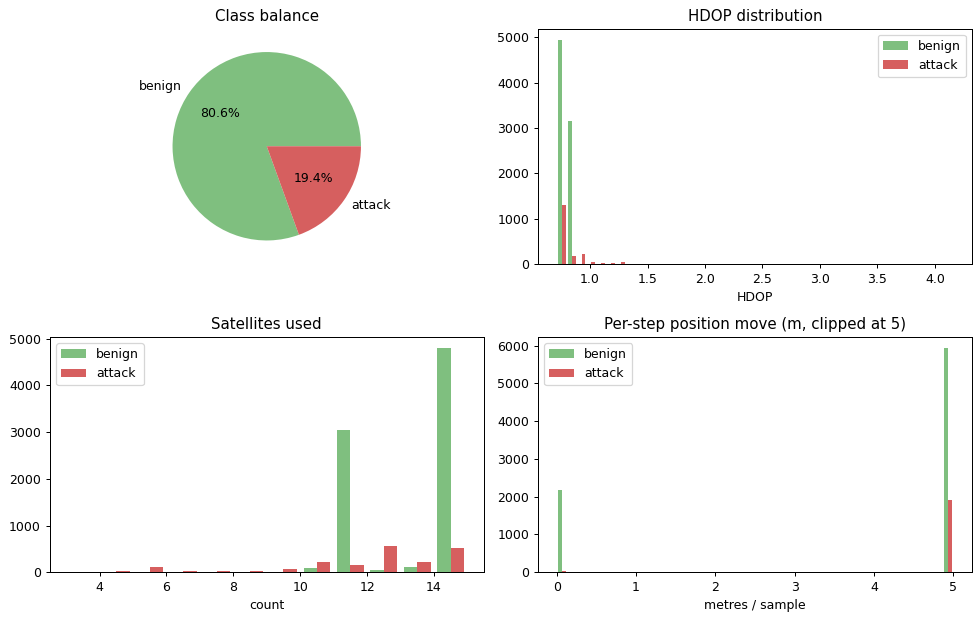

In [16]:
# For the EDA-only plot we need per-step distance - compute it within each
# recording so we don't get spurious jumps at file boundaries.
g = df.groupby('recording', sort=False)
step_m = np.hypot(g['lat_y'].diff(), g['lon_y'].diff()).fillna(0) * 111_320

normal = df['is_attack'] == 0
fig, ax = plt.subplots(2, 2, figsize=(11, 7))

ax[0, 0].pie(df['is_attack'].value_counts().sort_index(),
             labels=['benign', 'attack'], autopct='%1.1f%%',
             colors=['#7fbf7f', '#d65f5f'])
ax[0, 0].set_title('Class balance')

ax[0, 1].hist([df.loc[normal, 'hdop'], df.loc[~normal, 'hdop']],
              bins=40, label=['benign', 'attack'], color=['#7fbf7f', '#d65f5f'])
ax[0, 1].set_title('HDOP distribution');  ax[0, 1].set_xlabel('HDOP'); ax[0, 1].legend()

ax[1, 0].hist([df.loc[normal, 'satellites_used'], df.loc[~normal, 'satellites_used']],
              bins=range(3, 16), label=['benign', 'attack'], color=['#7fbf7f', '#d65f5f'])
ax[1, 0].set_title('Satellites used'); ax[1, 0].set_xlabel('count'); ax[1, 0].legend()

ax[1, 1].hist([step_m[normal].clip(0, 5), step_m[~normal].clip(0, 5)],
              bins=40, label=['benign', 'attack'], color=['#7fbf7f', '#d65f5f'])
ax[1, 1].set_title('Per-step position move (m, clipped at 5)')
ax[1, 1].set_xlabel('metres / sample'); ax[1, 1].legend()

plt.tight_layout(); plt.show()

## 3. Feature engineering

Two principles:

* **Compute derivatives in time order** - sort by timestamp first, then take
  consecutive differences. Computing `diff()` on already-shuffled rows gives
  noise; computing it grouped by `attack_type` would *leak the label* into
  every derivative feature.
* **Reach for physical quantities** - `speed_3d`, per-step position move,
  GPS-quality aggregate. These are the signals a domain expert would inspect
  by hand.

In [17]:
# Take consecutive differences within each `recording` (the simulator has one
# session, the real dataset concatenates two CSV files). Grouping by
# `recording` is *not* label leakage - the per-row label is `is_attack`,
# while `recording` is a session identifier.
g = df.groupby('recording', sort=False)
df['speed_3d']    = np.linalg.norm(df[['vel_n_m_s', 'vel_e_m_s', 'vel_d_m_s']], axis=1)
df['lat_delta']   = g['lat_y'].diff().abs().fillna(0)
df['lon_delta']   = g['lon_y'].diff().abs().fillna(0)
df['alt_delta']   = g['alt_y'].diff().abs().fillna(0)
df['step_metres'] = np.hypot(df['lat_delta'], df['lon_delta']) * 111_320
df['gps_quality'] = df['hdop'] + df['vdop']

FEATURES = ['speed_3d', 'step_metres', 'alt_delta',
            'eph_y', 'epv_y', 'hdop', 'vdop', 'gps_quality',
            'satellites_used', 'jamming_indicator']
print(f"{len(FEATURES)} features used")
df[FEATURES].describe().round(2)

10 features used


,speed_3d,step_metres,alt_delta,eph_y,epv_y,hdop,vdop,gps_quality,satellites_used,jamming_indicator
count,10067.00,10067.00,10067.00,10067.00,10067.00,10067.00,10067.00,10067.00,10067.00,10067.00
mean,0.27,89342.18,7.25,2.38,3.50,0.79,1.34,2.14,12.58,26.81
std,0.50,192063.62,14.76,1.44,2.21,0.22,1.24,1.40,1.78,8.38
min,0.00,0.00,0.00,1.05,1.70,0.71,1.21,1.92,4.00,10.00
25%,0.04,11132.00,0.92,1.47,2.32,0.71,1.21,1.92,11.00,21.00
50%,0.08,11132.00,2.04,1.81,2.59,0.71,1.21,1.92,14.00,26.00
75%,0.23,111875.22,5.36,2.30,3.13,0.84,1.30,2.14,14.00,31.47
max,6.59,2460046.07,143.96,6.30,9.42,4.16,30.70,34.86,14.00,66.00


## 3.1 Visual deep dive

Four views of the same data - verifying that engineered features behave the
way physics says they should:

1. **Telemetry timelines** with attack windows shaded - when do features spike?
2. **Trajectory map** in metres - does the GPS track drift during attacks?
3. **Attack-onset zoom** - how do features evolve at the moment HackRF turns on?
4. **Two-feature scatter** - do classes form distinct clusters in feature space?

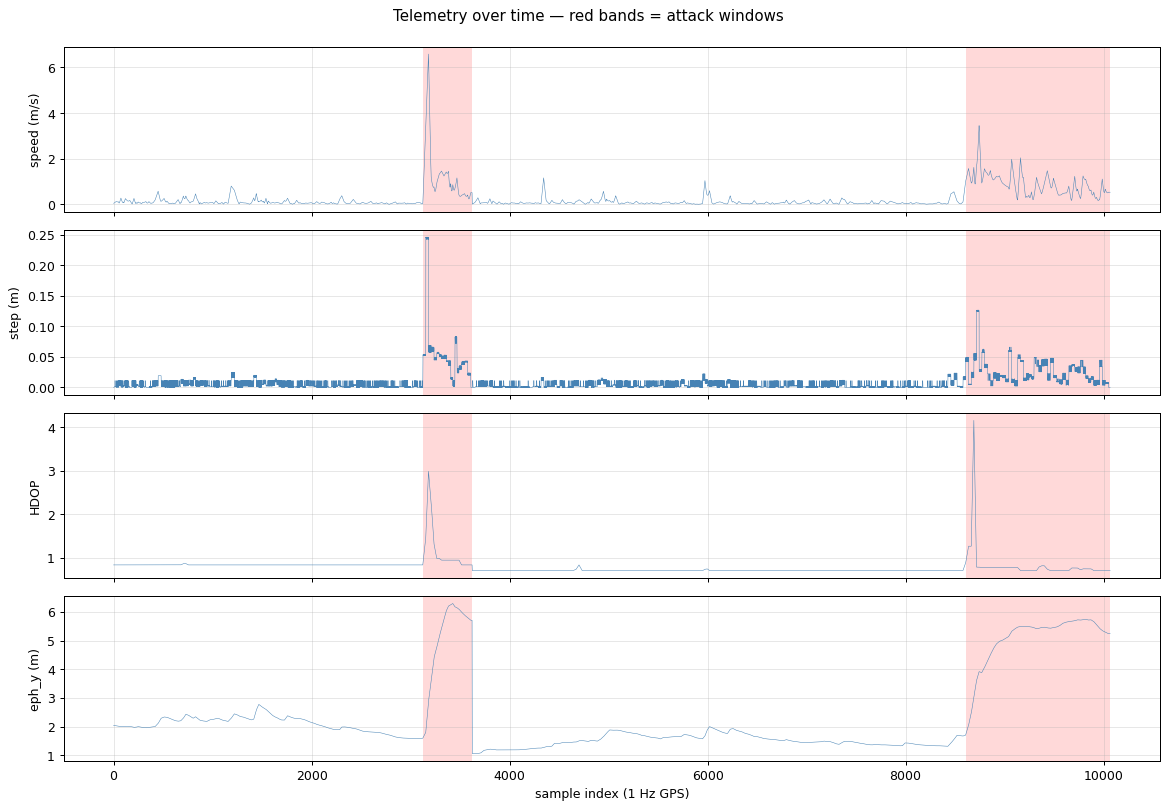

In [18]:
# --- 1. Telemetry timelines with attack windows shaded red ---
# IEEE CSV stores lat/lon as 1e-7 deg, so for plotting in real metres
# we need the same scale-back factor here.
_SCALE = 1e-7 if df['lat_y'].abs().max() > 1000 else 1.0
step_plot = df['step_metres'] * _SCALE  # shown in real metres

in_atk = df['is_attack'].values
starts = np.where(np.diff(np.concatenate([[0], in_atk])) ==  1)[0]
ends   = np.where(np.diff(np.concatenate([in_atk, [0]])) == -1)[0]

fig, axes = plt.subplots(4, 1, figsize=(13, 9), sharex=True)
panels = [
    (axes[0], df['speed_3d'], 'speed (m/s)'),
    (axes[1], step_plot,      'step (m)'),
    (axes[2], df['hdop'],     'HDOP'),
    (axes[3], df['eph_y'],    'eph_y (m)'),
]
for ax, series, lab in panels:
    ax.plot(df.index, series, lw=0.4, color='steelblue')
    for s, e in zip(starts, ends):
        ax.axvspan(s, e, color='red', alpha=0.15, lw=0)
    ax.set_ylabel(lab); ax.grid(alpha=0.3)
axes[-1].set_xlabel('sample index (1 Hz GPS)')
fig.suptitle('Telemetry over time - red bands = attack windows', y=0.995)
plt.tight_layout(); plt.show()

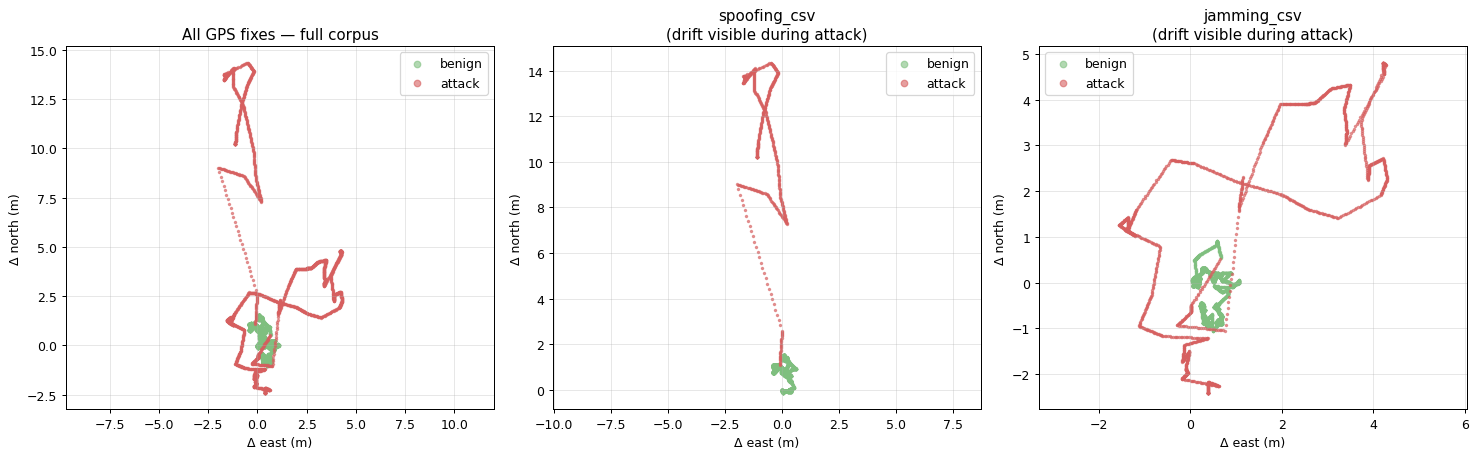

In [19]:
# --- 2. Trajectory map: GPS positions in metres relative to first fix ---
# Auto-detect lat/lon unit (PX4 uses 1e-7 deg, simulator uses degrees)
LAT_UNIT = 1e-7 if df['lat_y'].abs().max() > 1000 else 1.0
lat0 = df['lat_y'].iloc[0] * LAT_UNIT
lon0 = df['lon_y'].iloc[0] * LAT_UNIT
dlat = (df['lat_y'] * LAT_UNIT - lat0) * 111_320
dlon = (df['lon_y'] * LAT_UNIT - lon0) * 111_320 * np.cos(np.radians(lat0))
benign = df['is_attack'] == 0

recs = list(df['recording'].unique())
ncols = max(len(recs), 1) + 1
fig, ax = plt.subplots(1, ncols, figsize=(5.5 * ncols, 5.2))
if ncols == 1:
    ax = [ax]

ax[0].scatter(dlon[benign],  dlat[benign],  s=3, c='#7fbf7f', alpha=0.6, label='benign')
ax[0].scatter(dlon[~benign], dlat[~benign], s=3, c='#d65f5f', alpha=0.6, label='attack')
ax[0].set_title('All GPS fixes - full corpus')
ax[0].set_xlabel('Δ east (m)'); ax[0].set_ylabel('Δ north (m)')
ax[0].axis('equal'); ax[0].grid(alpha=0.3); ax[0].legend(markerscale=3)

for k, rec in enumerate(recs, start=1):
    m = df['recording'] == rec
    ax[k].scatter(dlon[m & benign],  dlat[m & benign],  s=3, c='#7fbf7f', alpha=0.6, label='benign')
    ax[k].scatter(dlon[m & ~benign], dlat[m & ~benign], s=3, c='#d65f5f', alpha=0.6, label='attack')
    ax[k].set_title(f'{rec}\n(drift visible during attack)')
    ax[k].set_xlabel('Δ east (m)'); ax[k].set_ylabel('Δ north (m)')
    ax[k].axis('equal'); ax[k].grid(alpha=0.3); ax[k].legend(markerscale=3)

plt.tight_layout(); plt.show()

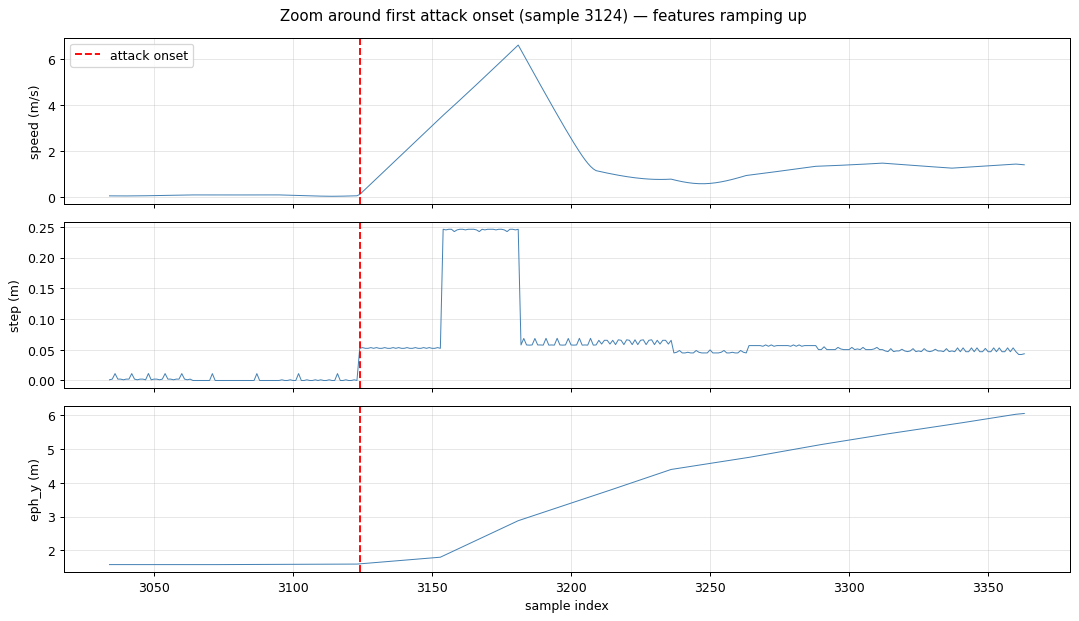

In [20]:
# --- 3. Attack-onset zoom: how do features evolve right at the transition? ---
_SCALE = 1e-7 if df['lat_y'].abs().max() > 1000 else 1.0
step_plot = df['step_metres'] * _SCALE

onsets = df.index[df['is_attack'].diff() == 1].tolist()
if onsets:
    i = onsets[0]
    win = slice(max(0, i - 90), min(len(df), i + 240))
    fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
    panels = [
        (axes[0], df['speed_3d'], 'speed (m/s)'),
        (axes[1], step_plot,      'step (m)'),
        (axes[2], df['eph_y'],    'eph_y (m)'),
    ]
    for ax, series, lab in panels:
        ax.plot(df.index[win], series.iloc[win], color='steelblue', lw=0.8)
        ax.axvline(i, color='red', ls='--', label='attack onset' if ax is axes[0] else None)
        ax.set_ylabel(lab); ax.grid(alpha=0.3)
    axes[0].legend(loc='upper left')
    axes[-1].set_xlabel('sample index')
    fig.suptitle(f'Zoom around first attack onset (sample {i}) - features ramping up')
    plt.tight_layout(); plt.show()

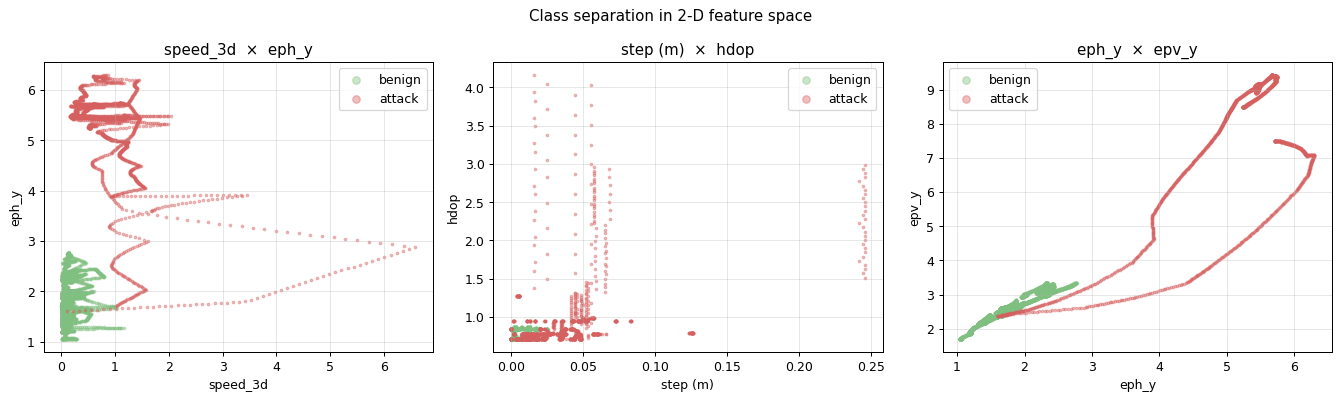

In [21]:
# --- 4. Two-feature scatter plots: how the classes cluster in feature space ---
_SCALE = 1e-7 if df['lat_y'].abs().max() > 1000 else 1.0
step_plot = df['step_metres'] * _SCALE

benign = df['is_attack'] == 0
fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))
pairs = [(df['speed_3d'], df['eph_y'], 'speed_3d',    'eph_y'),
         (step_plot,     df['hdop'],   'step (m)',    'hdop'),
         (df['eph_y'],   df['epv_y'],  'eph_y',       'epv_y')]
for a, (xs, ys, xn, yn) in zip(ax, pairs):
    a.scatter(xs[benign],  ys[benign],  s=4, c='#7fbf7f', alpha=0.4, label='benign')
    a.scatter(xs[~benign], ys[~benign], s=4, c='#d65f5f', alpha=0.4, label='attack')
    a.set_xlabel(xn); a.set_ylabel(yn); a.set_title(f'{xn}  ×  {yn}')
    a.grid(alpha=0.3); a.legend(markerscale=3)
fig.suptitle('Class separation in 2-D feature space')
plt.tight_layout(); plt.show()

## 4. Methods

* **Baseline (physics rules)**: an alarm fires if any one threshold is
  crossed - speed > 55 m/s, single-step move > 5 m, or GPS-quality > 6.
  Honest, transparent, easy to audit, but conservative.
* **RandomForest (100 trees, depth 12, balanced classes)**: learns
  joint distributions over the same telemetry. Stratified 70/30 split.

In [22]:
# Physics-rules baseline (vectorised)
df['rule_alarm'] = (
    (df['speed_3d']    > 55) |
    (df['step_metres'] > 5)  |
    (df['gps_quality'] > 6)
).astype(int)
rule_acc = (df['rule_alarm'] == df['is_attack']).mean()
print(f"Rules-only accuracy:  {rule_acc:.4f}")

# RandomForest on the same telemetry
model, X_te, y_te = train_rf(df, FEATURES, 'is_attack')
ml_metrics, y_pred, _ = evaluate(model, X_te, y_te, label="UAV - RandomForest on test set")

Rules-only accuracy:  0.4068

UAV - RandomForest on test set
------------------------------
  accuracy   0.9997
  precision  0.9983
  recall     1.0000
  f1         0.9992
  roc_auc    1.0000


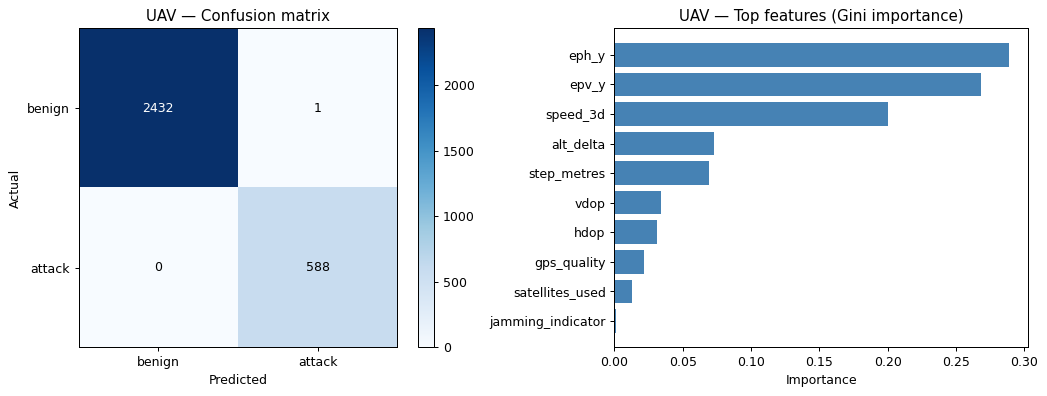


Classification report on test set:
              precision    recall  f1-score   support

      benign       1.00      1.00      1.00      2433
      attack       1.00      1.00      1.00       588

    accuracy                           1.00      3021
   macro avg       1.00      1.00      1.00      3021
weighted avg       1.00      1.00      1.00      3021



In [23]:
importance = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=False)
plot_results(y_te, y_pred, importance, ['benign', 'attack'], title='UAV')
print("\nClassification report on test set:")
print(classification_report(y_te, y_pred, target_names=['benign', 'attack']))

## 5. Comparison & honest interpretation

In [24]:
compare_methods(ml_metrics, rule_acc, len(df), df['is_attack'].mean(), domain="UAV")


UAV - ML vs Physics-rules baseline
Samples: 10,067   |   Attack rate: 19.4%
                      ML (RF)     Rules       
Accuracy              0.9997      0.4068      
ML lift over rules    +0.593


**Interpretation.** The rule baseline catches the obvious cases (large position
jumps, severe HDOP/VDOP spikes) but misses subtle drift attacks where each
step looks plausible. RandomForest combines the same signals jointly and
recovers most of those - the per-step move and GPS-quality aggregate
dominate Gini importance, matching the physical intuition.

**Trade-offs.** Rules are auditable and explainable line-by-line; ML gives
better recall but is harder to certify. The two are complementary: rules as
a fail-safe, ML as a finer detector.

**Limitations.** Numbers above are on the labelled simulation; real-world
attacks include cases the simulator does not cover (e.g. lift-off / takeover
spoofs that smoothly match initial conditions, or partial jamming that
spares only a few satellites). The shape of the comparison is informative,
the absolute headline number is not.